In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Advertising.csv')

In [3]:
df.head(4)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5


In [4]:
df.tail(2)

,Unnamed: 0,TV,Radio,Newspaper,Sales
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [5]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='str')

In [6]:
df.drop(columns=['Radio', 'Newspaper','Unnamed: 0'],inplace=True)

In [7]:
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


In [8]:
x=df[['TV']]
y=df['Sales']

In [9]:
x.head(1)

,TV
0,230.1


In [10]:
y.head(1)

0    22.1
Name: Sales, dtype: float64

****NOW WE NEED TO TRAIN AND TEST DATA***

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=50)

****train the data we use fit****

In [12]:
from sklearn.linear_model import LinearRegression
slr=LinearRegression(fit_intercept=True)#LinearRegression() → algorithm
#fit_intercept=True → tells model to calculate β₀ (intercept)
#No learning has happened yet 
#You are just preparing the model to learn later
slr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
slr.intercept_

np.float64(6.845633135106893)

In [14]:
slr.coef_

array([0.04992806])

In [15]:
y_pred=slr.predict(x_test).flatten()
print("Prediction test: {}".format(y_pred))

Prediction test: [15.61799312 18.55376299  8.03392094 13.30632398 11.64871242 17.74992124
 18.43393565  7.27501444 18.22923061 11.25428075 18.81838171 15.68289959
 17.67003635 15.45822333 19.97171987 13.59590672 12.88692829 18.24420903
  8.99253968 13.42115852 12.32773402 10.60521598  9.95615122 17.94963348
 20.51094291 10.26071238 11.35912968 11.62374839 16.07733126 17.17075576
 12.99177721 14.32485639  7.68941733 16.71141761 10.66013685  9.07741738
 11.9732448  19.96173426 11.19935989 10.66013685]


In [16]:
slr_diff = pd.DataFrame({'Actual value': y_test.values, 'Predicted value': y_pred.flatten()})
slr_diff.head()

,Actual value,Predicted value
0,14.1,15.617993
1,11.9,18.553763
2,9.2,8.033921
3,11.0,13.306324
4,11.4,11.648712


In [17]:
slr_diff['Error']=slr_diff['Actual value']-slr_diff['Predicted value']

In [18]:
slr_diff.head()

,Actual value,Predicted value,Error
0,14.1,15.617993,-1.517993
1,11.9,18.553763,-6.653763
2,9.2,8.033921,1.166079
3,11.0,13.306324,-2.306324
4,11.4,11.648712,-0.248712


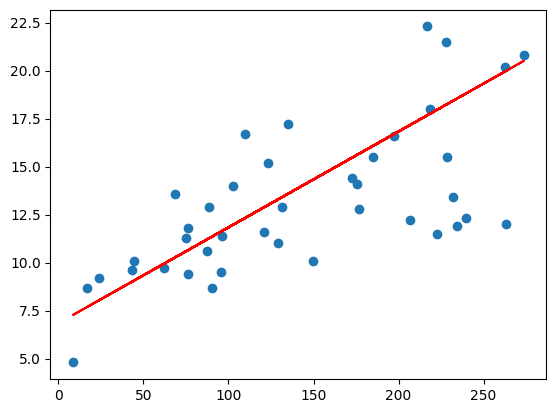

In [19]:
plt.scatter(x_test,y_test)
plt.plot(x_test,y_pred,'Red')

In [ ]:
from sklearn import metrics
meanAbberr=metrics.mean_absolute_error(y_test,y_pred)
meanSqerr=metrics.mean_squared_error(y_test,y_pred)
rootmeansquare=np.sqrt(metrics.mean_squared_error(y_test,y_pred))
print('R squared: {:.2f}'.format(mlr.score(X,y)*100))
print("mean square error",meanSqerr)
print("mean absolute error",meanAbberr)
print("root square",rootmeansquare)


mean square error 9.982774399876993
mean absolute error 2.3991903508120678
root square 3.15955287974058
